# Exploratory Data Analysis — Higgs Twitter Dataset

This notebook explores the `higgs-activity_time.txt.gz` dataset before model training.
We visualize temporal patterns, network structure, degree distributions, and influence score distributions.

> **Run `preprocess.py` first** to generate `data/processed/events.parquet`.

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import networkx as nx
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

EVENTS_PATH = '../data/processed/events.parquet'
INTERACTION_NAMES = {0: 'Retweet (RT)', 1: 'Mention (MT)', 2: 'Reply (RE)'}
COLORS = {0: '#2196F3', 1: '#4CAF50', 2: '#FF9800'}

df = pd.read_parquet(EVENTS_PATH)
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df['interaction_name'] = df['interaction_type'].map(INTERACTION_NAMES)

print(f'Total events:   {len(df):,}')
print(f'Unique users:   {pd.concat([df.src, df.dst]).nunique():,}')
print(f'Time range:     {df.datetime.min()} → {df.datetime.max()}')
print(f'Duration:       {(df.datetime.max() - df.datetime.min()).days} days')
df.head()

Total events:   563,069
Unique users:   304,691
Time range:     2012-07-01 00:02:52 → 2012-07-07 23:59:53
Duration:       6 days


,src,dst,timestamp,interaction_type,datetime,interaction_name
0,223789,213163,1341100972,1,2012-07-01 00:02:52,Mention (MT)
1,223789,213163,1341100972,2,2012-07-01 00:02:52,Reply (RE)
2,376989,50329,1341101181,0,2012-07-01 00:06:21,Retweet (RT)
3,26375,168366,1341101183,1,2012-07-01 00:06:23,Mention (MT)
4,376989,13813,1341101192,0,2012-07-01 00:06:32,Retweet (RT)


## 1. Temporal Activity Timeline

How did interaction volume change over the 7-day window around the Higgs boson announcement?

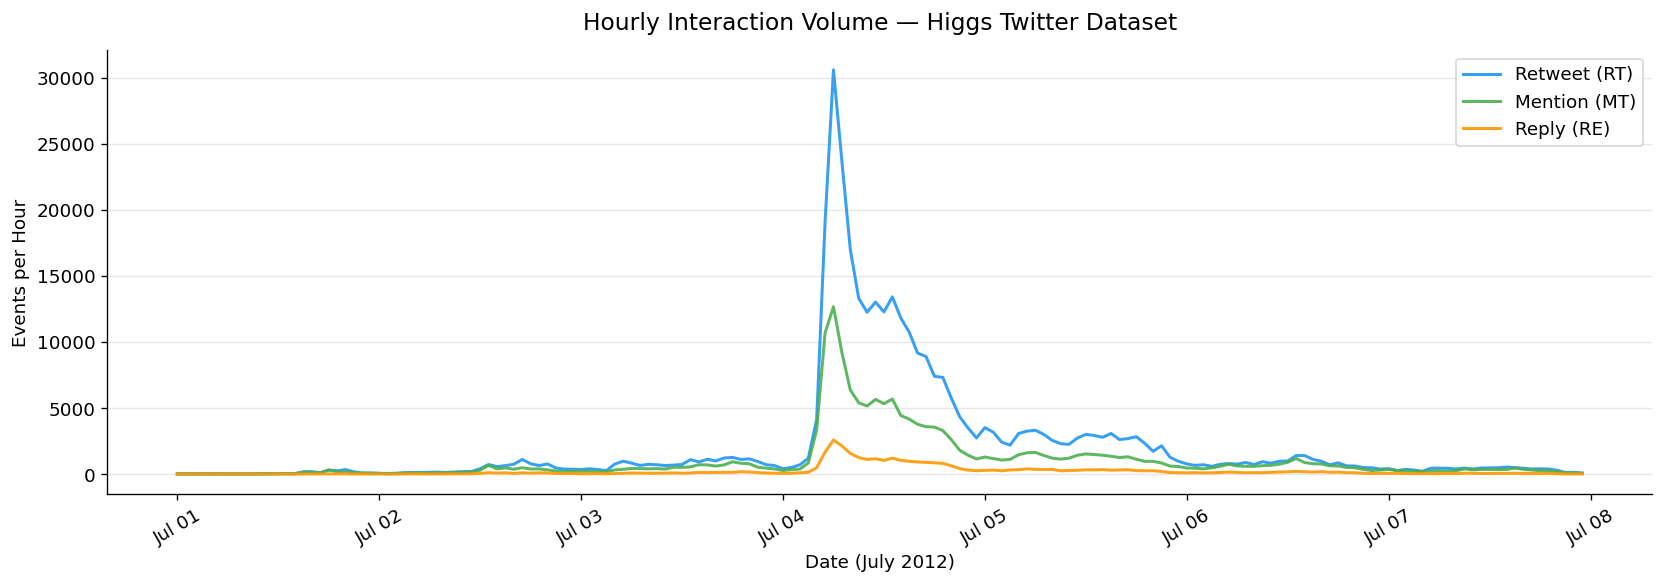

Peak hour (overall): 2012-07-04 06:00:00


In [2]:
df['hour_bin'] = df['datetime'].dt.floor('h')

hourly = (
    df.groupby(['hour_bin', 'interaction_type'])
    .size()
    .reset_index(name='count')
)
hourly['interaction_name'] = hourly['interaction_type'].map(INTERACTION_NAMES)

fig, ax = plt.subplots(figsize=(14, 5))
for itype, group in hourly.groupby('interaction_type'):
    ax.plot(
        group['hour_bin'], group['count'],
        label=INTERACTION_NAMES[itype],
        color=COLORS[itype], linewidth=1.8, alpha=0.9
    )

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=30)
ax.set_title('Hourly Interaction Volume — Higgs Twitter Dataset', fontsize=14, pad=12)
ax.set_xlabel('Date (July 2012)')
ax.set_ylabel('Events per Hour')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/eda_activity_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

print('Peak hour (overall):', df.groupby('hour_bin').size().idxmax())

## 2. Interaction Type Breakdown

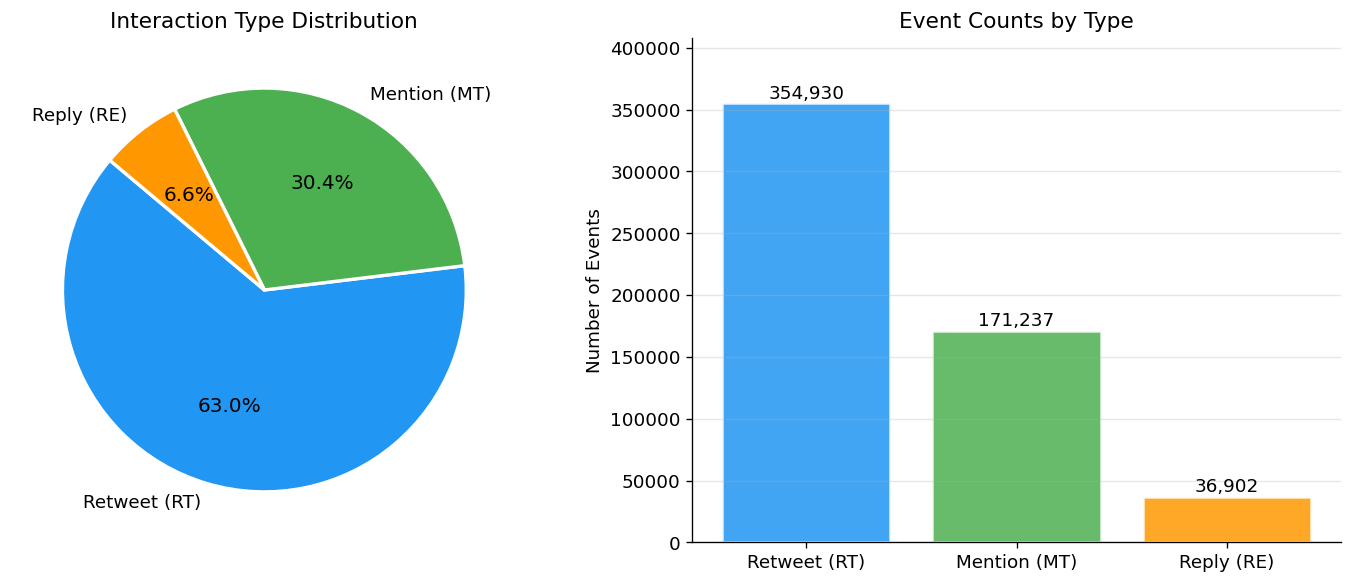

In [3]:
counts = df['interaction_type'].value_counts().sort_index()
labels = [INTERACTION_NAMES[i] for i in counts.index]
color_list = [COLORS[i] for i in counts.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

wedges, texts, autotexts = ax1.pie(
    counts.values, labels=labels, colors=color_list,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(12)
ax1.set_title('Interaction Type Distribution', fontsize=13)

bars = ax2.bar(labels, counts.values, color=color_list, alpha=0.85, edgecolor='white', linewidth=1.5)
ax2.set_title('Event Counts by Type', fontsize=13)
ax2.set_ylabel('Number of Events')
for bar, val in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{val:,}', ha='center', va='bottom', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.savefig('../outputs/plots/eda_interaction_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Degree Distribution (Power Law Check)

Social networks typically follow a power-law degree distribution (scale-free). We verify this with a log-log plot.

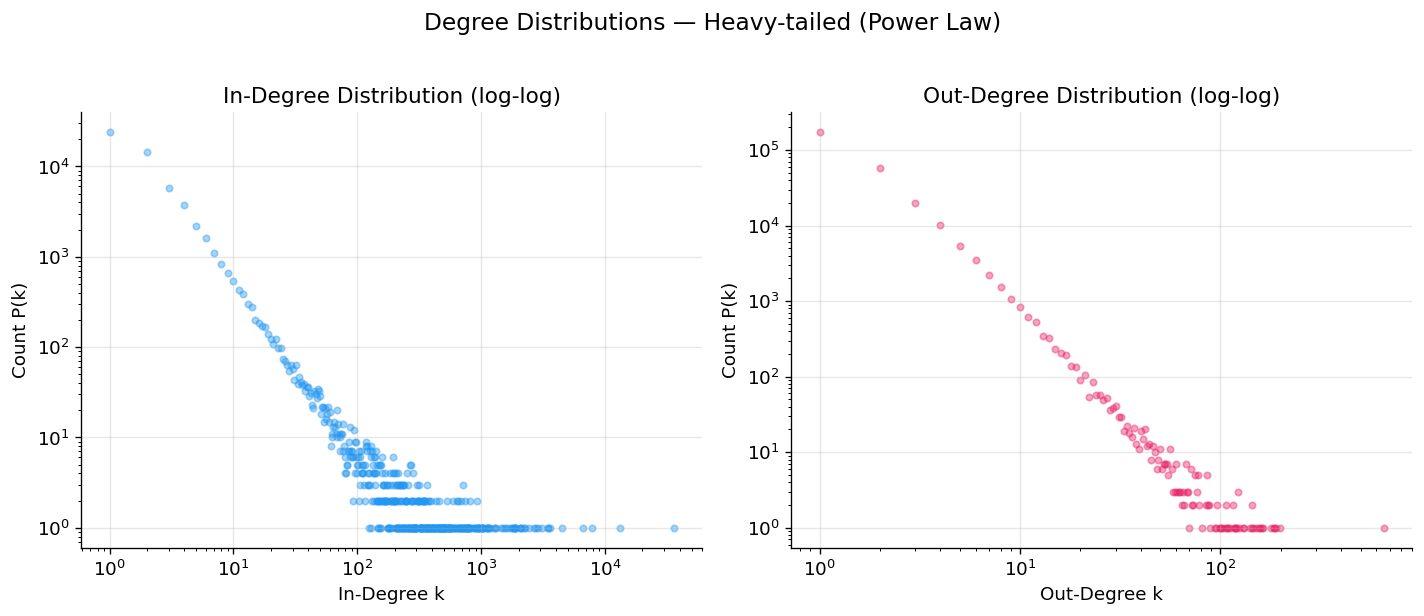

In-degree  — max: 35,988, mean: 9.4, median: 2.0
Out-degree — max: 656, mean: 2.0, median: 1.0


In [4]:
in_degree = df['dst'].value_counts()
out_degree = df['src'].value_counts()

def degree_distribution(degrees):
    counts = degrees.value_counts().sort_index()
    return counts.index.values, counts.values

in_k, in_count = degree_distribution(in_degree)
out_k, out_count = degree_distribution(out_degree)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(in_k, in_count, alpha=0.4, s=15, color='#2196F3')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('In-Degree Distribution (log-log)', fontsize=13)
axes[0].set_xlabel('In-Degree k')
axes[0].set_ylabel('Count P(k)')
axes[0].grid(alpha=0.3)

axes[1].scatter(out_k, out_count, alpha=0.4, s=15, color='#E91E63')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Out-Degree Distribution (log-log)', fontsize=13)
axes[1].set_xlabel('Out-Degree k')
axes[1].set_ylabel('Count P(k)')
axes[1].grid(alpha=0.3)

plt.suptitle('Degree Distributions — Heavy-tailed (Power Law)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/plots/eda_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'In-degree  — max: {in_degree.max():,}, mean: {in_degree.mean():.1f}, median: {in_degree.median()}')
print(f'Out-degree — max: {out_degree.max():,}, mean: {out_degree.mean():.1f}, median: {out_degree.median()}')

## 4. Top 20 Influencers

Users ranked by total incoming interactions (retweets + mentions + replies received).

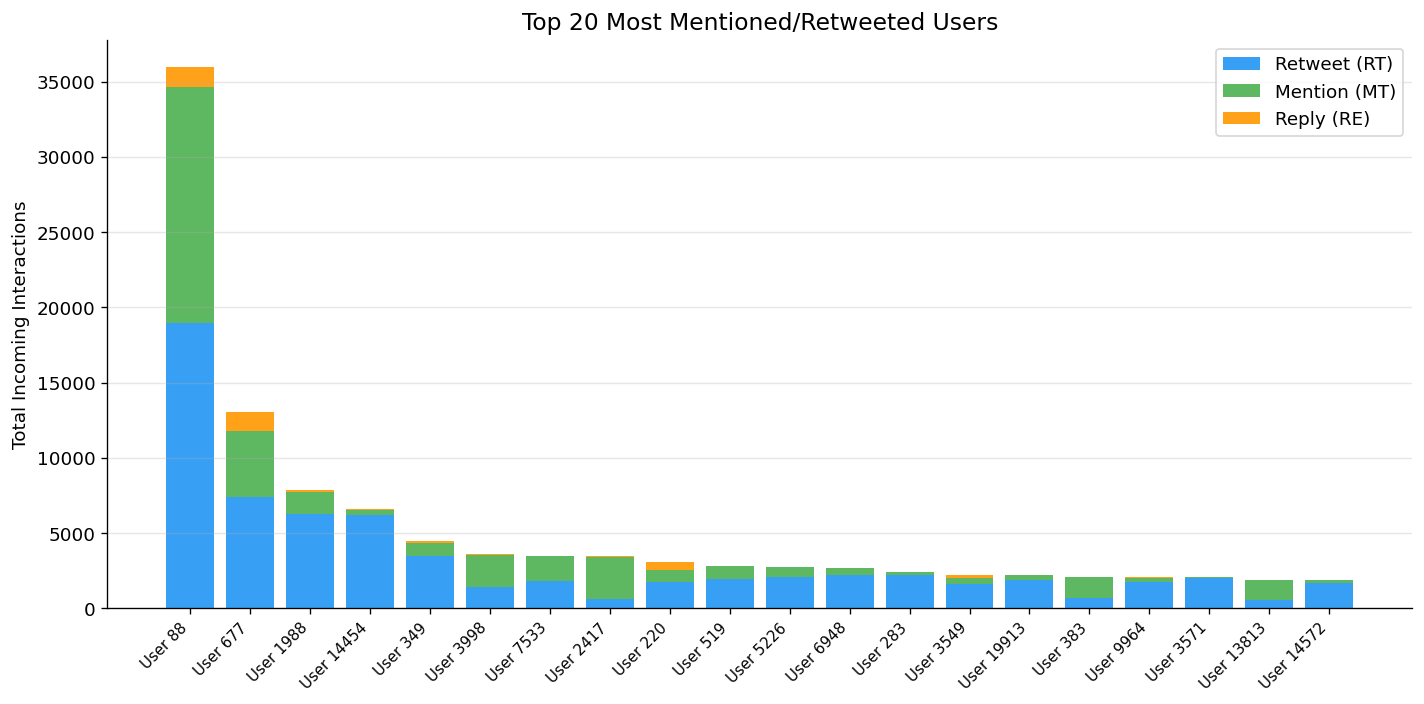

In [5]:
influence_by_type = (
    df.groupby(['dst', 'interaction_type'])
    .size()
    .unstack(fill_value=0)
    .rename(columns=INTERACTION_NAMES)
)
influence_by_type['total'] = influence_by_type.sum(axis=1)
top20 = influence_by_type.nlargest(20, 'total')

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(top20))
xticks = np.arange(len(top20))

for itype, col_name in INTERACTION_NAMES.items():
    if col_name in top20.columns:
        ax.bar(xticks, top20[col_name].values, bottom=bottom,
               label=col_name, color=COLORS[itype], alpha=0.9)
        bottom += top20[col_name].values

ax.set_xticks(xticks)
ax.set_xticklabels([f'User {uid}' for uid in top20.index], rotation=45, ha='right', fontsize=9)
ax.set_title('Top 20 Most Mentioned/Retweeted Users', fontsize=14)
ax.set_ylabel('Total Incoming Interactions')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Network Visualization (200-node Subgraph)

A sample of the most active 200 users, colored by dominant interaction type.

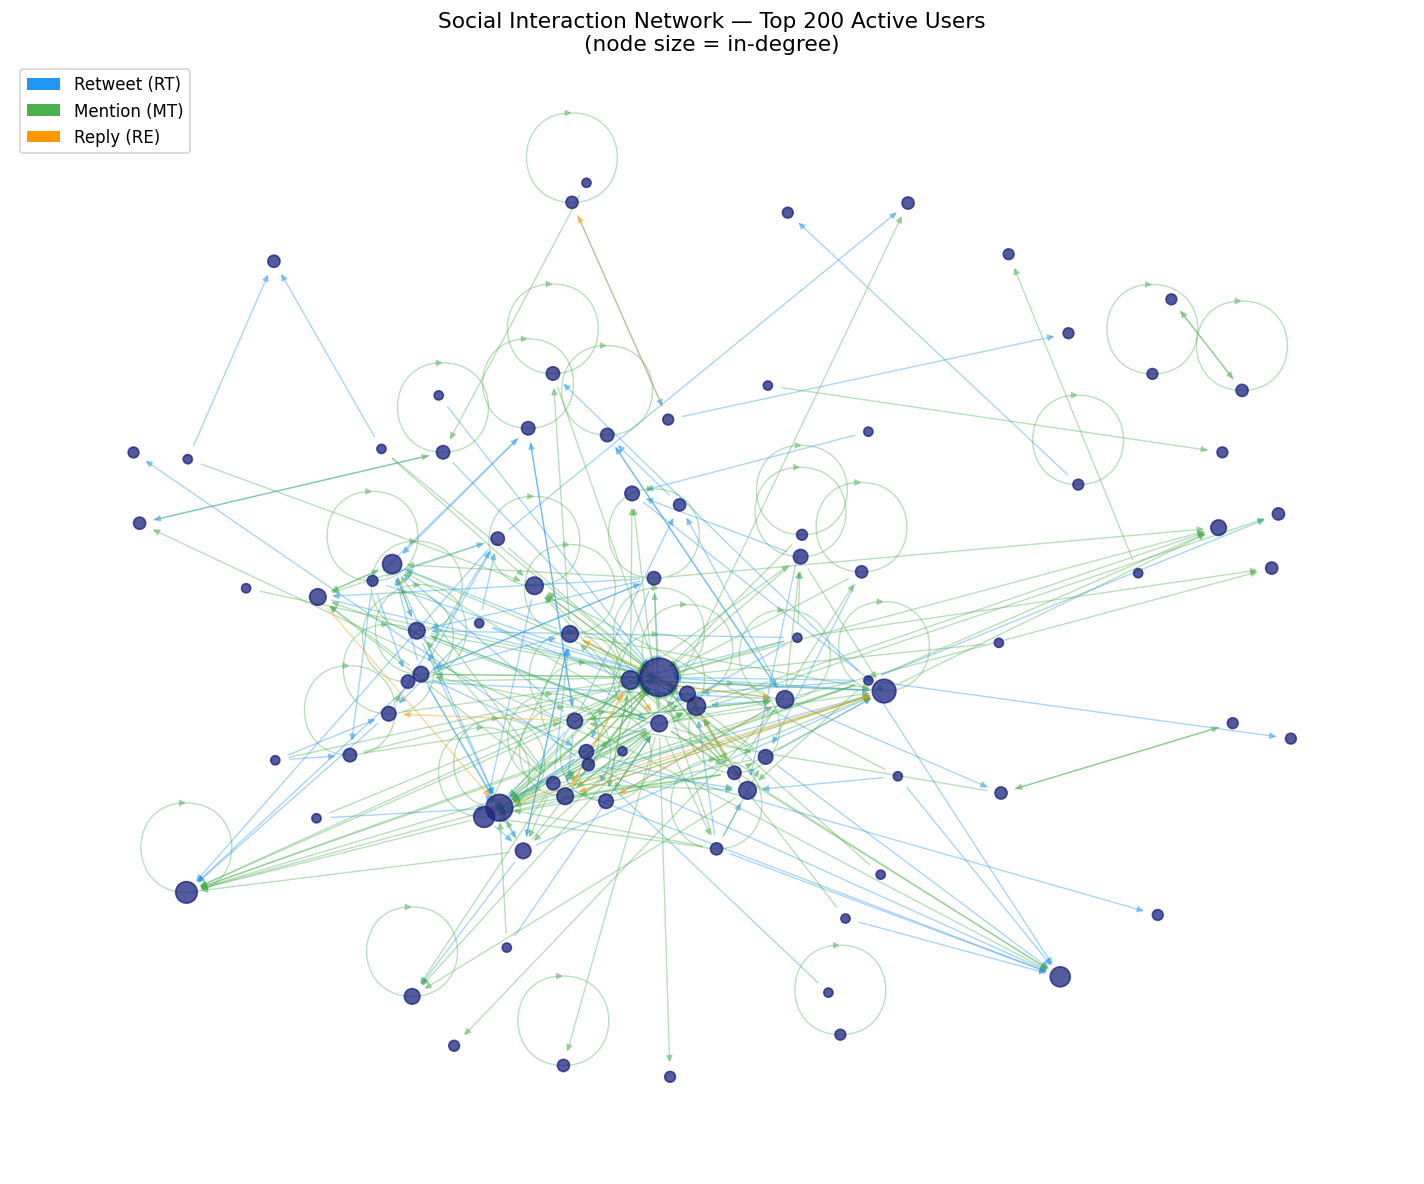

Subgraph: 89 nodes, 315 edges
Density: 0.040220


In [6]:
top_users = set(
    pd.concat([df['src'], df['dst']])
    .value_counts()
    .head(200)
    .index
)

sub_df = df[df['src'].isin(top_users) & df['dst'].isin(top_users)]
G = nx.from_pandas_edgelist(
    sub_df.head(1000),
    source='src', target='dst',
    edge_attr='interaction_type',
    create_using=nx.DiGraph()
)

node_in = dict(G.in_degree())
max_in = max(node_in.values()) if node_in else 1
node_sizes = [30 + 500 * (node_in.get(n, 0) / max_in) for n in G.nodes()]

fig, ax = plt.subplots(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42, k=0.5)

for itype, color in COLORS.items():
    edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('interaction_type') == itype]
    nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=color,
                           alpha=0.4, arrows=True, arrowsize=8,
                           ax=ax, width=0.8)

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#1A237E',
                       alpha=0.75, ax=ax)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS[i], label=INTERACTION_NAMES[i]) for i in range(3)]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
ax.set_title('Social Interaction Network — Top 200 Active Users\n(node size = in-degree)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Subgraph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'Density: {nx.density(G):.6f}')

## 6. Influence Score Distribution

Distribution of per-user incoming interaction counts across all 6-hour windows.
The vertical dashed line marks the 90th percentile (our influence threshold).

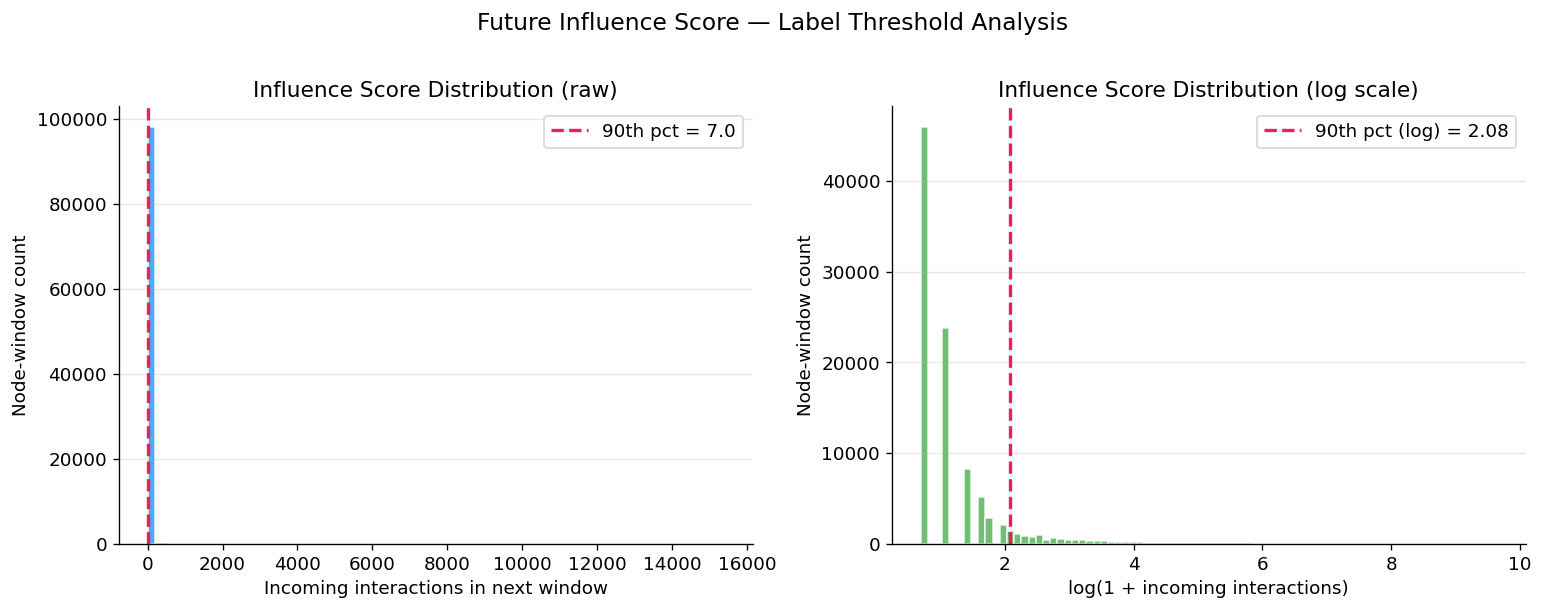

90th percentile threshold: 7.0
Positive class rate: 10.5%
Class imbalance ratio (neg:pos): 8.5:1


In [7]:
import math

WINDOW_HOURS = 6
window_sec = WINDOW_HOURS * 3600
t_min = int(df['timestamp'].min())
t_max = int(df['timestamp'].max())
n_windows = math.ceil((t_max - t_min) / window_sec)

all_influence_scores = []
for i in range(n_windows - 1):
    t_start = t_min + (i + 1) * window_sec
    t_end = t_start + window_sec
    next_events = df[(df['timestamp'] >= t_start) & (df['timestamp'] < t_end)]
    if len(next_events) == 0:
        continue
    scores = next_events['dst'].value_counts()
    all_influence_scores.extend(scores.values.tolist())

scores_arr = np.array(all_influence_scores, dtype=float)
scores_arr = scores_arr[scores_arr > 0]
threshold = np.percentile(scores_arr, 90)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(scores_arr, bins=80, color='#2196F3', alpha=0.8, edgecolor='white')
axes[0].axvline(threshold, color='#E91E63', linewidth=2, linestyle='--',
               label=f'90th pct = {threshold:.1f}')
axes[0].set_title('Influence Score Distribution (raw)', fontsize=13)
axes[0].set_xlabel('Incoming interactions in next window')
axes[0].set_ylabel('Node-window count')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(np.log1p(scores_arr), bins=80, color='#4CAF50', alpha=0.8, edgecolor='white')
axes[1].axvline(np.log1p(threshold), color='#E91E63', linewidth=2, linestyle='--',
               label=f'90th pct (log) = {np.log1p(threshold):.2f}')
axes[1].set_title('Influence Score Distribution (log scale)', fontsize=13)
axes[1].set_xlabel('log(1 + incoming interactions)')
axes[1].set_ylabel('Node-window count')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Future Influence Score — Label Threshold Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

pct_influential = (scores_arr >= threshold).mean() * 100
print(f'90th percentile threshold: {threshold:.1f}')
print(f'Positive class rate: {pct_influential:.1f}%')
print(f'Class imbalance ratio (neg:pos): {100/pct_influential - 1:.1f}:1')

## 7. Temporal Activity Heatmap

Activity intensity per 6-hour window for the top 50 most active users.

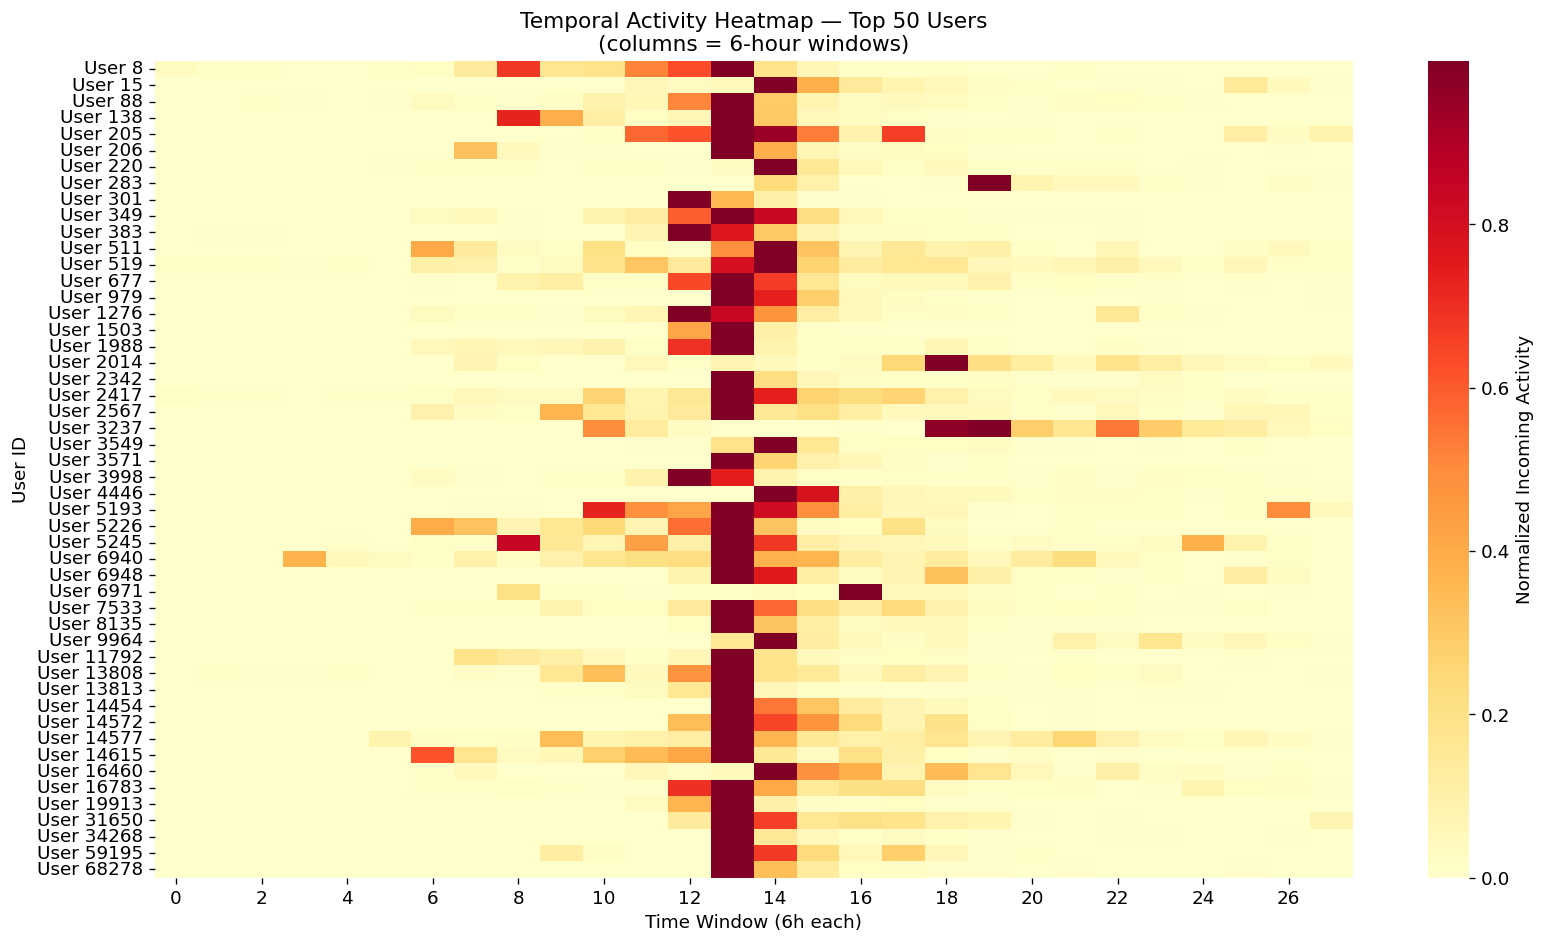

In [8]:
top50_users = pd.concat([df['src'], df['dst']]).value_counts().head(50).index.tolist()

df['window'] = ((df['timestamp'] - t_min) // window_sec).astype(int)
sub = df[df['dst'].isin(top50_users)]

heatmap_data = (
    sub.groupby(['dst', 'window'])
    .size()
    .unstack(fill_value=0)
)
# Normalize per user for visual clarity
heatmap_norm = heatmap_data.div(heatmap_data.max(axis=1) + 1, axis=0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    heatmap_norm,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0,
    xticklabels=2,
    yticklabels=[f'User {u}' for u in heatmap_norm.index],
    cbar_kws={'label': 'Normalized Incoming Activity'}
)
ax.set_title('Temporal Activity Heatmap — Top 50 Users\n(columns = 6-hour windows)', fontsize=13)
ax.set_xlabel('Time Window (6h each)')
ax.set_ylabel('User ID')
plt.tight_layout()
plt.show()

## 8. Summary Statistics

In [9]:
summary = {
    'Total events': f"{len(df):,}",
    'Unique users': f"{pd.concat([df.src, df.dst]).nunique():,}",
    'Retweet events': f"{(df.interaction_type == 0).sum():,}",
    'Mention events': f"{(df.interaction_type == 1).sum():,}",
    'Reply events': f"{(df.interaction_type == 2).sum():,}",
    'Max in-degree': f"{in_degree.max():,}",
    'Max out-degree': f"{out_degree.max():,}",
    'Number of snapshots (6h)': n_windows,
    'Influence threshold (90th pct)': f"{threshold:.1f}",
    'Positive class rate': f"{pct_influential:.1f}%",
}

print('=' * 45)
print('  DATASET SUMMARY')
print('=' * 45)
for k, v in summary.items():
    print(f'  {k:<35} {v}')
print('=' * 45)

  DATASET SUMMARY
  Total events                        563,069
  Unique users                        304,691
  Retweet events                      354,930
  Mention events                      171,237
  Reply events                        36,902
  Max in-degree                       35,988
  Max out-degree                      656
  Number of snapshots (6h)            28
  Influence threshold (90th pct)      7.0
  Positive class rate                 10.5%
